In [197]:
from PyHessian.pyhessian.hessian import hessian
from PyHessian.density_plot import get_esd_plot
from hessian_utils import *
from PyHessian.pyhessian.utils import *
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
# from keras.datasets import mnist
import matplotlib.pyplot as plt 
import time
import copy


# PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
%matplotlib inline

In [198]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)
cuda = torch.cuda.is_available()
torch.autograd.set_detect_anomaly(True)

cuda


In [199]:
mnist_trainset = datasets.MNIST(root='../data/mnist', train=True, download=True, transform=transforms.ToTensor())
mnist_fashion_trainset = datasets.FashionMNIST(root='../data/fashion_mnist', train=True, download=True, transform=transforms.ToTensor())
cifar_trainset = datasets.CIFAR10(root='../data/cifar10', train=True, download=True, transform=transforms.ToTensor())
# Getting mnist test data
mnist_testset = datasets.MNIST(root='../data/mnist', train=False, download=True, transform=transforms.ToTensor())
mnist_fashion_testset = datasets.FashionMNIST(root='../data/fashion_mnist', train=False, download=True, transform=transforms.ToTensor())
cifar_testset = datasets.CIFAR10(root='../data/cifar10', train=False, download=True, transform=transforms.ToTensor())

In [200]:
train_X = cifar_trainset.data
train_y = cifar_trainset.targets
test_X = cifar_testset.data
test_y = cifar_testset.targets

In [201]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)
        self.fc2 = nn.Linear(100, 30)
        self.fc3 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(16*7*7, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 16*7*7)
        x = self.linear(x)
        return x

class ConvNet3D(nn.Module):
    def __init__(self):
        super(ConvNet3D, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(40*8*8, 30),
            nn.ReLU(),
            nn.Linear(30, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 40*8*8)
        x = self.linear(x)
        return x

In [202]:
train_X = torch.tensor(train_X).permute(0, 3, 1, 2).float()
test_X = torch.tensor(test_X).permute(0, 3, 1, 2).float()
train_X = (train_X / 255.0).to(device)
test_X = (test_X / 255.0).to(device)
train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

In [203]:
torch.manual_seed(42)
np.random.seed(42)
n_samples = 1000
batch_size = 32

In [204]:
train_X = train_X[:n_samples]
train_y = train_y[:n_samples]

dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X, train_y),
    batch_size=batch_size, shuffle=True)

In [205]:
criterion_SGD = nn.CrossEntropyLoss()
criterion_Adam = nn.CrossEntropyLoss()
criterion_Curvy = nn.CrossEntropyLoss()

model_base = ConvNet3D().to(device)
model_SGD = copy.deepcopy(model_base)
model_Adam = copy.deepcopy(model_base)
model_curvy = copy.deepcopy(model_base)

In [206]:
train_losses_SGD = []
train_losses_Adam = []
train_losses_curvy = []

model_distance_SGD = []
model_distance_Adam = []
model_distance_curvy = []

In [207]:
def mean_curvature(curvature):
    return [torch.tensor(np.mean([curvature[i][j] for i in range(len(curvature))], axis=0)).to(device) for j in range(len(curvature[0]))]

def distance(model1, model2):
    return sum([torch.norm(p1 - p2) for p1, p2 in zip(model1.parameters(), model2.parameters())])

def get_loss(model, loader, criterion):
    total_loss = 0
    total_items = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss_value = criterion(outputs, labels)
            total_loss += loss_value.item() * inputs.size(0)
            total_items += inputs.size(0)
    return total_loss / total_items

def set_zero_parameters(model):
    for param in model.parameters():
        param.data.zero_()
            

In [208]:
epochs = 30
n_iter = 100
n_hess_samples = 50
adam_lr = 5e-3
sgd_lr = 1e-2
curvy_lr = 5e-3
curvy_eps = 1
sgd_mom = 0.9
curvy_mom =0.9

In [209]:
criterion = nn.CrossEntropyLoss()
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=sgd_lr, momentum=sgd_mom)
optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr=adam_lr)
optimizer_curvy = torch.optim.Adam(model_curvy.parameters(), lr=curvy_lr)

In [210]:
hessian_loader = (train_X[:n_hess_samples], train_y[:n_hess_samples])

hessian_SGD = hessian(model_SGD, criterion, data = hessian_loader, cuda=cuda)
hessian_Adam = hessian(model_Adam, criterion, data = hessian_loader, cuda=cuda)
hessian_curvy = hessian(model_curvy, criterion, data = hessian_loader, cuda=cuda)

curvature_SGD = (hessian_SGD.curvature_array(n_iter, 1e-3))
curvature_Adam = (hessian_Adam.curvature_array(n_iter, 1e-3))
curvature_curvy = (hessian_curvy.curvature_array(n_iter, 1e-3))

mean_curvature_SGD = mean_curvature(curvature_SGD)
mean_curvature_Adam = mean_curvature(curvature_Adam)
mean_curvature_curvy = mean_curvature(curvature_curvy)

model_distance_SGD.append(distance(model_SGD, model_base))
model_distance_Adam.append(distance(model_Adam, model_base))
model_distance_curvy.append(distance(model_curvy, model_base))

In [211]:
for epoch in range(epochs):
    indices = torch.randperm(train_X.size(0))[:n_hess_samples]
    random_hessian_loader = (train_X[indices], train_y[indices])

    hessian_curvy = hessian(model_curvy, criterion, data = random_hessian_loader, cuda=cuda)
    curvature_curvy = hessian_curvy.curvature_array(n_iter, 1e-3)
    mean_curvature_curvy = mean_curvature(curvature_curvy)

    model_SGD.train()
    model_Adam.train()
    model_curvy.train()

    running_loss_SGD = 0.0
    running_loss_Adam = 0.0
    running_loss_curvy = 0.0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer_SGD.zero_grad()
        optimizer_Adam.zero_grad()
        optimizer_curvy.zero_grad()

        # Forward pass
        outputs_SGD = model_SGD(inputs)
        outputs_Adam = model_Adam(inputs)
        outputs_curvy = model_curvy(inputs)

        # Compute loss
        loss_SGD = criterion(outputs_SGD, labels)
        loss_Adam = criterion(outputs_Adam, labels)
        loss_curvy = criterion(outputs_curvy, labels)

        # Backward pass and optimize
        loss_SGD.backward()
        loss_Adam.backward()
        loss_curvy.backward()

        for param, cur in zip(model_curvy.parameters(), mean_curvature_curvy):
            if param.grad is None:
                continue
            param.grad = param.grad/torch.max(torch.abs(cur), torch.ones_like(cur) * curvy_eps)

        optimizer_SGD.step()
        optimizer_Adam.step()
        optimizer_curvy.step()

        running_loss_SGD += loss_SGD.item()
        running_loss_Adam += loss_Adam.item()
        running_loss_curvy += loss_curvy.item()

    train_losses_SGD.append(running_loss_SGD / len(dataloader))
    train_losses_Adam.append(running_loss_Adam / len(dataloader))
    train_losses_curvy.append(running_loss_curvy / len(dataloader))

    model_distance_SGD.append(distance(model_SGD, model_base))
    model_distance_Adam.append(distance(model_Adam, model_base))
    model_distance_curvy.append(distance(model_curvy, model_base))
    print(f"Epoch [{epoch+1}/{epochs}], Loss SGD: {train_losses_SGD[-1]:.4f}, Loss Adam: {train_losses_Adam[-1]:.4f}, loss Curvy: {train_losses_curvy[-1]:.4f}")

Epoch [1/30], Loss SGD: 2.3055, Loss Adam: 2.3003, loss Curvy: 2.3003
Epoch [2/30], Loss SGD: 2.2994, Loss Adam: 2.1447, loss Curvy: 2.1412
Epoch [3/30], Loss SGD: 2.2932, Loss Adam: 1.9421, loss Curvy: 1.9453
Epoch [4/30], Loss SGD: 2.2776, Loss Adam: 1.8035, loss Curvy: 1.8342
Epoch [5/30], Loss SGD: 2.2093, Loss Adam: 1.6716, loss Curvy: 1.7188
Epoch [6/30], Loss SGD: 2.1387, Loss Adam: 1.6269, loss Curvy: 1.6320
Epoch [7/30], Loss SGD: 2.0372, Loss Adam: 1.5522, loss Curvy: 1.5797
Epoch [8/30], Loss SGD: 1.9911, Loss Adam: 1.5440, loss Curvy: 1.4476
Epoch [9/30], Loss SGD: 1.8810, Loss Adam: 1.4436, loss Curvy: 1.4343
Epoch [10/30], Loss SGD: 1.8652, Loss Adam: 1.3957, loss Curvy: 1.3511
Epoch [11/30], Loss SGD: 1.8421, Loss Adam: 1.3421, loss Curvy: 1.3282
Epoch [12/30], Loss SGD: 1.8007, Loss Adam: 1.2343, loss Curvy: 1.1828
Epoch [13/30], Loss SGD: 1.7303, Loss Adam: 1.1287, loss Curvy: 1.0682
Epoch [14/30], Loss SGD: 1.6546, Loss Adam: 1.0799, loss Curvy: 1.0572
Epoch [15/30], 

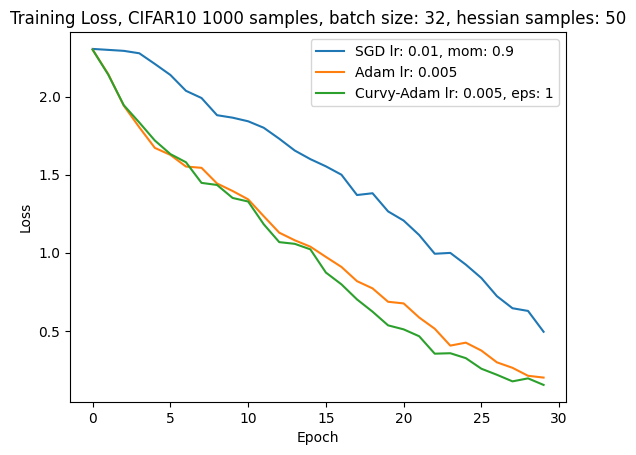

In [215]:
plt.plot(train_losses_SGD, label=f'SGD lr: {sgd_lr}, mom: {sgd_mom}')
plt.plot(train_losses_Adam, label=f'Adam lr: {adam_lr}')
plt.plot(train_losses_curvy, label=f'Curvy-Adam lr: {curvy_lr}, eps: {curvy_eps}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training Loss, CIFAR10 {n_samples} samples, batch size: {batch_size}, hessian samples: {n_hess_samples}')
plt.legend()
plt.show()

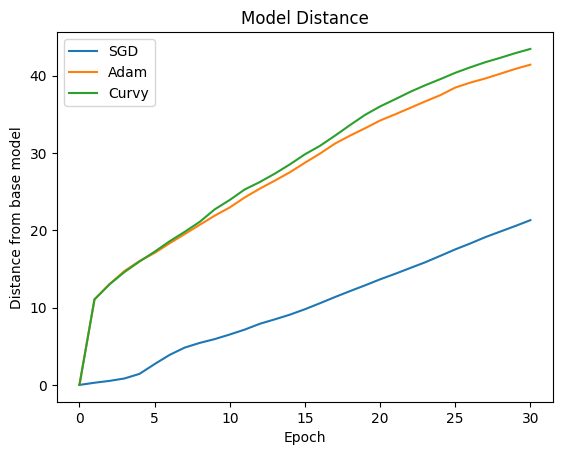

In [213]:
plt.plot([model_distance_SGD[i].detach().item() for i in range(len(model_distance_SGD))], label='SGD')
plt.plot([model_distance_Adam[i].detach().item() for i in range(len(model_distance_Adam))], label='Adam')
plt.plot([model_distance_curvy[i].detach().item() for i in range(len(model_distance_curvy))], label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Distance from base model')
plt.title('Model Distance')
plt.legend()
plt.show()

In [214]:
distance(model_curvy, model_Adam), distance(model_curvy, model_SGD), distance(model_Adam, model_SGD)

(tensor(36.2119, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(47.5761, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(45.5761, device='cuda:0', grad_fn=<AddBackward0>))